In [2]:
import cv2 # opencv 读取的是 BGR 格式
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

img = cv2.imread("figure.jpeg")

In [3]:
img

array([[[184, 101,  45],
        [184, 101,  45],
        [183, 100,  44],
        ...,
        [184,  99,  43],
        [184,  99,  43],
        [184,  99,  43]],

       [[184, 101,  45],
        [184, 101,  45],
        [183, 100,  44],
        ...,
        [186, 101,  45],
        [186, 101,  45],
        [186, 101,  45]],

       [[184, 101,  45],
        [184, 101,  45],
        [184, 101,  45],
        ...,
        [187, 102,  46],
        [187, 102,  46],
        [187, 102,  46]],

       ...,

       [[  3,  17,  40],
        [  2,  16,  39],
        [  1,  15,  38],
        ...,
        [  2, 109, 176],
        [  1, 105, 170],
        [  0, 103, 166]],

       [[  1,  21,  46],
        [  0,  20,  45],
        [  0,  19,  44],
        ...,
        [  2, 109, 176],
        [  0, 104, 169],
        [  0, 102, 165]],

       [[  2,  27,  53],
        [  1,  26,  52],
        [  0,  25,  51],
        ...,
        [  2, 109, 176],
        [  0, 104, 169],
        [  1, 101, 165]]

In [4]:
# 图像的显示，也可以创建多个窗口
cv2.imshow('image', img)

# 等待时间，毫秒级别，0表示按任意键终止
cv2.waitKey(0)
cv2.destroyAllWindows()

In [8]:
def cv_show(name, img):
    cv2.imshow(name, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [8]:
img.shape # h, w, 3:rgb

(384, 580, 3)

In [9]:
# 读取灰度图
img = cv2.imread("figure.jpeg",cv2.IMREAD_GRAYSCALE)
img

array([[ 94,  94,  93, ...,  92,  92,  92],
       [ 94,  94,  93, ...,  94,  94,  94],
       [ 94,  94,  94, ...,  95,  95,  95],
       ...,
       [ 22,  21,  20, ..., 117, 113, 110],
       [ 26,  25,  24, ..., 117, 112, 109],
       [ 32,  31,  30, ..., 117, 112, 109]], dtype=uint8)

In [10]:
img.shape

(384, 580)

In [11]:
cv2.imshow("gray image", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
cv2.imwrite("gray_image.jpeg", img)

True

In [13]:
type(img)

numpy.ndarray

In [14]:
img.size

222720

In [15]:
img.dtype

dtype('uint8')

## 视频读取

In [16]:
vc = cv2.VideoCapture("test.mp4")

In [17]:
# 检查是否打开正确
if vc.isOpened():
    open, frame = vc.read()
else :
    open = False

In [18]:
while open:
    ret, frame = vc.read()
    if frame is None:
        break
    if ret == True:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imshow("result", gray)
        if cv2.waitKey(10) & 0xFF == 27: # 27 表示退出建
            break

vc.release()
cv2.destroyAllWindows()

## 截取部分图像数据

In [9]:
img = cv2.imread("figure.jpeg")
flower = img[0:200, 0:200]
cv_show("flower", flower)

## 颜色通道提取

In [20]:
b,g,r = cv2.split(img)

In [21]:
b

array([[184, 184, 183, ..., 184, 184, 184],
       [184, 184, 183, ..., 186, 186, 186],
       [184, 184, 184, ..., 187, 187, 187],
       ...,
       [  3,   2,   1, ...,   2,   1,   0],
       [  1,   0,   0, ...,   2,   0,   0],
       [  2,   1,   0, ...,   2,   0,   1]], dtype=uint8)

In [22]:
g.shape

(384, 580)

In [23]:
# 重新组合在一起
img = cv2.merge((b,g,r))
img.shape

(384, 580, 3)

In [24]:
# 只保留R
cur_img = img.copy()
cur_img[:, :, 0] = 0
cur_img[:,:,1] = 0
cv_show('R', cur_img)

In [25]:
# 只保留G
cur_img = img.copy()
cur_img[:,:,0] = 0
cur_img[:,:,2] = 0
cv_show("G", cur_img)

In [26]:
# 只保留B
cur_img = img.copy()
cur_img[:,:,1] = 0
cur_img[:,:,2] = 0
cv_show("blue",cur_img)

## 边界填充

In [29]:
top_size, bottom_size, left_size, right_size = (50,50,50,50)

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(img,top_size, bottom_size, left_size, right_size, cv2.BORDER_WRAP)
constant = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, cv2.BORDER_CONSTANT)


(<AxesSubplot:title={'center':'CONSTANT'}>,
 Text(0.5, 1.0, 'CONSTANT'))

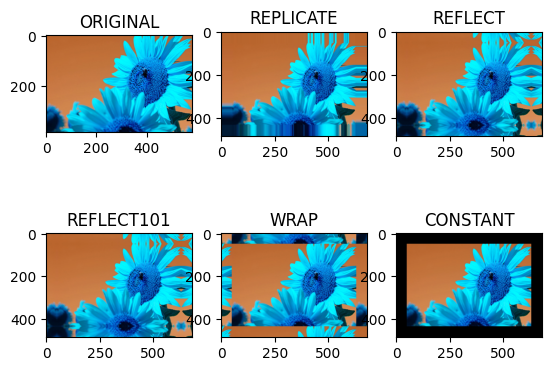

In [30]:
import matplotlib.pylab as plt
plt.subplot(231), plt.imshow(img, "gray"), plt.title("ORIGINAL")
plt.subplot(232), plt.imshow(replicate, "gray"), plt.title("REPLICATE")
plt.subplot(233), plt.imshow(reflect, "gray"), plt.title("REFLECT")
plt.subplot(234), plt.imshow(reflect101, "gray"), plt.title("REFLECT101")
plt.subplot(235), plt.imshow(wrap, "gray"), plt.title("WRAP")
plt.subplot(236), plt.imshow(constant, "gray"), plt.title("CONSTANT")


## 数值计算

In [31]:
img_flower = cv2.imread("figure.jpeg")
img_sky  = cv2.imread("sky.jpeg")

In [34]:
img_flower2 = img_flower + 10
img_flower2[:5,:,0]

array([[194, 194, 193, ..., 194, 194, 194],
       [194, 194, 193, ..., 196, 196, 196],
       [194, 194, 194, ..., 197, 197, 197],
       [196, 196, 196, ..., 196, 196, 196],
       [196, 196, 196, ..., 195, 195, 195]], dtype=uint8)

In [33]:
img_flower[:5,:,0]

array([[184, 184, 183, ..., 184, 184, 184],
       [184, 184, 183, ..., 186, 186, 186],
       [184, 184, 184, ..., 187, 187, 187],
       [186, 186, 186, ..., 186, 186, 186],
       [186, 186, 186, ..., 185, 185, 185]], dtype=uint8)

In [35]:
# 相当于 %256
(img_flower + img_flower2)[:5,:,0]

array([[122, 122, 120, ..., 122, 122, 122],
       [122, 122, 120, ..., 126, 126, 126],
       [122, 122, 122, ..., 128, 128, 128],
       [126, 126, 126, ..., 126, 126, 126],
       [126, 126, 126, ..., 124, 124, 124]], dtype=uint8)

In [36]:
cv2.add(img_flower, img_flower2)[:5,:,0]

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

## 图像融合

In [38]:
img_flower + img_sky

ValueError: operands could not be broadcast together with shapes (384,580,3) (500,749,3) 

In [37]:
img_flower.shape

(384, 580, 3)

In [40]:
img_sky = cv2.resize(img_sky, (580, 384))
img_sky.shape

(384, 580, 3)

In [41]:
res = cv2.addWeighted(img_flower, 0.4, img_sky, 0.6, 0)

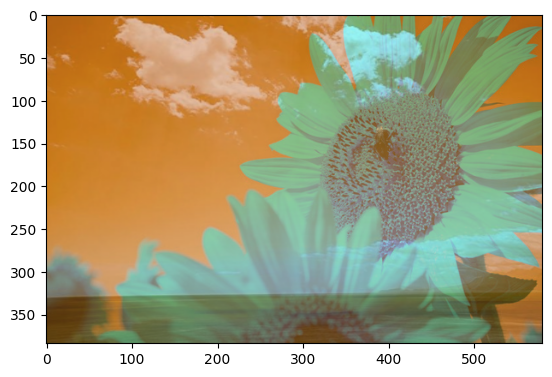

In [42]:
plt.imshow(res)

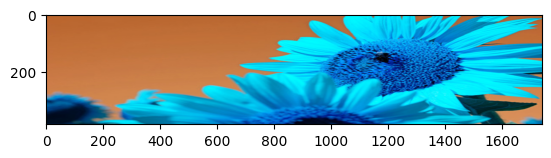

In [43]:
res = cv2.resize(img, (0,0), fx=3, fy=1)
plt.imshow(res)

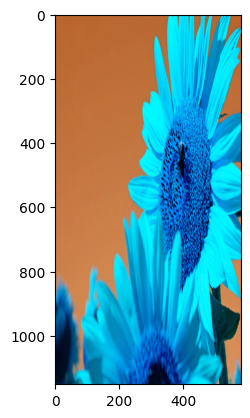

In [44]:
res = cv2.resize(img, (0, 0), fx=1, fy=3)
plt.imshow(res)

## 图像阈值

```
ret, dst = cv2.threshold(src, thresh, maxval, type)
```
- src: 输入图，只能输入单通道图像，通常来说是灰度图
- dst: 输出图
- thresh: 阈值
- maxval: 当像素超出了阈值（或者小于阈值，根据 type 来决定），所赋予的值
- type: 二值化操作的类型，包含以下5种类型：cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV， CV2.THRESH_TRUNC, CV2.THRESH_TOZERO, CV2.THRESH_TOZERO_INV

- cv2.THRESH_BINARY : 超过阈值部分取 maxval(最大值), 否则取0
- cv2.THRESH_BINARY_INV 是 cv2,THRESH_BINARY 的反转
- cv2.THRESH_TRUNC : 大于阈值部分设为阈值，否则不变
- cv.THRESH_TOZERO: 大于阈值部分不改变，否者设为0
- cv.THRESH_TOZERO_INV 是 cv2.THRESH_TOZERO 的反转



In [8]:
img_gray = cv2.imread("figure.jpeg", cv2.IMREAD_GRAYSCALE)

ret, thresh1 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ['Oringinal image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]



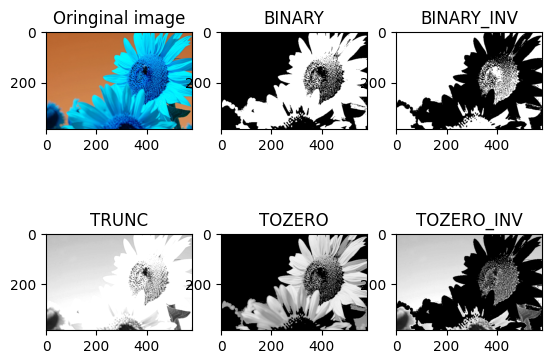

In [9]:
for i in range(6):
    plt.subplot(231+i), plt.imshow(images[i], 'gray'), plt.title(titles[i])

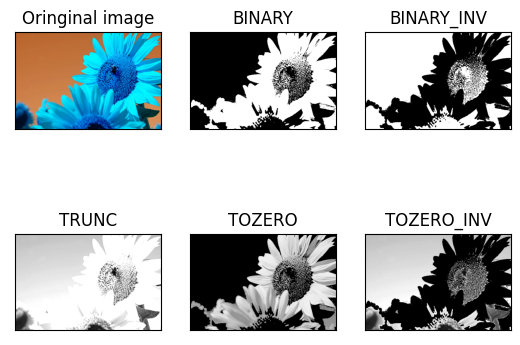

In [10]:
for i in range(6):
    plt.subplot(2,3,i+1), plt.imshow(images[i], 'gray'), plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

## 图像平滑

In [17]:
img = cv2.imread("lena.png")

cv2.imshow('img', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
# 均值滤波
# 简答的平均卷积操作

blur = cv2.blur(img, (3,3))
cv2.imshow('img', blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [27]:
# 方框滤波
# 基本和均值一样，可以选择归一化，选择归一化就和均值滤波一样了

box = cv2.boxFilter(img, -1, (3,3), normalize=True) # -1 表示原始数据和输出数据通道一致，一般默认为 -1

cv2.imshow('box_image', box)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite("box_image_T.png", box)

True

In [28]:
# 方框滤波
# 不选择归一化，可能会出现越界

box = cv2.boxFilter(img, -1, (3,3), normalize=False)
cv2.imshow("box_img_F", box)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite("box_image_T.png", box)

True

In [30]:
## 高斯滤波
## 高斯模糊的卷积核里的数值是满足高斯分布的，相当于更重视中间的

aussian = cv2.GaussianBlur(img, (5,5), 1)

cv2.imshow("Gaussian", aussian)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [32]:
# 中值滤波
# 相当于用中值替代

median = cv2.medianBlur(img, 5)

cv2.imshow("median", median)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
# 展示所有的
res = np.hstack((blur, aussian, median))
cv2.imshow("median vs average", res)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 形态学-腐蚀操作

In [5]:
img = cv2.imread("figure.jpeg")

cv2.imshow("Original_flower", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
kernel = np.ones((5,5), np.uint8)
erosion = cv2.erode(img, kernel, iterations = 1) # iterations 腐蚀的迭代次数

cv2.imshow("erosion", erosion)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [2]:
lena = cv2.imread("lena.png")

cv2.imshow("lena", lena)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
kernel = np.ones((30,30), np.uint8)

erosion_1 = cv2.erode(lena, kernel, iterations = 1)
erosion_2 = cv2.erode(lena, kernel, iterations = 2)
erosion_3 = cv2.erode(lena, kernel, iterations = 3)

res = np.hstack((erosion_1, erosion_2, erosion_3))
cv2.imshow("res", res)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 形态学-膨胀操作

In [8]:
img = cv2.imread("lena.png")
cv2.imshow("lena", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [9]:
kernel = np.ones((3,3), np.uint8)
erosion = cv2.erode(img, kernel, iterations = 1)

cv2.imshow("erosion", erosion)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [11]:
kernel = np.ones((3,3), np.uint8)
dilate = cv2.dilate(erosion, kernel, iterations=1)

cv2.imshow("dilate", dilate)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
sky = cv2.imread("sky.jpeg")
kernel = np.ones((3,3), np.uint8)

dilate_1 = cv2.dilate(sky, kernel, iterations=1)
dilate_2 = cv2.dilate(sky, kernel, iterations=2)
dilate_3 = cv2.dilate(sky, kernel, iterations=3)

res = np.hstack((dilate_1, dilate_2, dilate_3))
cv2.imshow("res", res)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 开运算与闭运算

In [2]:
# 开：先腐蚀再膨胀
img = cv2.imread("figure.jpeg")

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

cv2.imshow('opening', opening)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# 闭：先膨胀，再腐蚀
img = cv2.imread("figure.jpeg")

kernel = np.ones((3,3), np.uint8)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

cv2.imshow("closing", closing)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 梯度运算

In [2]:
# 梯度 = 膨胀 - 腐蚀
flower = cv2.imread("figure.jpeg")
kernel = np.ones((3,3), np.uint8)
dilate = cv2.dilate(flower, kernel, iterations = 5)
erosion = cv2.erode(flower,kernel, iterations = 5)

res = np.hstack((dilate, erosion))

cv2.imshow('res', res)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [4]:
gradient = cv2.morphologyEx(flower, cv2.MORPH_GRADIENT, kernel)

cv2.imshow('gradient', gradient)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 礼帽与黑帽
- 礼帽 = 原始输入 - 开运算结果
- 黑帽 = 闭运算 - 原始输入

In [ ]:
# 礼帽
img = cv2.imread("figure.jpeg")
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
cv2.imshow("tophat", tophat)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
# 黑帽
img = cv2.imread("figure.jpeg")
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
cv2.imshow('blackhat', blackhat)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Sobel 算子公式

梯度幅值：
$$
G = \sqrt{G_x^2 + G_y^2}
$$

简化近似：
$$
G = |G_x| + |G_y|
$$

Sobel X 核：
$$
G_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

Sobel Y 核：
$$
G_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

In [6]:
img = cv2.imread("figure.jpeg", cv2.IMREAD_GRAYSCALE)
cv2.imshow('figure_gray', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

```python
dst = cv2.Sobel(src, ddepth, dx, dy, ksize)
```
- ddepth : 图像的深度
- dx 和 dy 分别表示水平和竖直方向
- ksize 是 Sobel 算子的大小

In [4]:
def cv_show(img, name):
    cv2.imshow(name, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [9]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
cv_show(sobelx, 'sobelx')

In [10]:
## 白到黑是正数，黑到白就是负数了，所有的负数会被截断成0，所以要取绝对值
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
cv_show(sobelx, 'sobelx')

In [ ]:
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobely = cv2.convertScaleAbs(sobely)
cv_show(sobely, 'sobely')

## 分别计算 x 和 y，再求和

In [13]:
sobelxy = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)
cv_show(sobelxy, 'sobelxy')

In [14]:
# 不建议直接计算
sobelxy = cv2.Sobel(img, cv2.CV_64F, 1,1, ksize=3)
sobelxy = cv2.convertScaleAbs(sobelxy)
cv_show(sobelxy, 'sobelxy')

In [16]:
img = cv2.imread("board.png", cv2.IMREAD_GRAYSCALE)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobely = cv2.convertScaleAbs(sobely)
sobelxy = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)
cv_show(sobelxy, 'sobelxy')

In [18]:
img = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)

sobelxy = cv2.Sobel(img, cv2.CV_64F, 1, 1, ksize=3)
sobelxy = cv2.convertScaleAbs(sobelxy)
cv_show(sobelxy, 'sobelxy')

## Scharr 算子

### Scharr 卷积核

Scharr X（水平方向，检测垂直边缘）：
$$
G_x =
\begin{bmatrix}
-3 & 0 & 3 \\
-10 & 0 & 10 \\
-3 & 0 & 3
\end{bmatrix}
$$

Scharr Y（垂直方向，检测水平边缘）：
$$
G_y =
\begin{bmatrix}
-3 & -10 & -3 \\
0 & 0 & 0 \\
3 & 10 & 3
\end{bmatrix}
$$

### 梯度幅值
$$
G = \sqrt{G_x^2 + G_y^2}
$$

---

## Laplacian 算子（拉普拉斯算子）

### 标准 3×3 Laplacian 核
$$
\nabla^2 I =
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

### 带对角线增强版本
$$
\nabla^2 I =
\begin{bmatrix}
1 & 1 & 1 \\
1 & -8 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

### 数学定义
$$
\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

In [22]:
# 不同算子之间的差异
img = cv2.imread('board.png', cv2.IMREAD_GRAYSCALE)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize = 3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)
sobelxy = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)



scharr_x = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharr_x = cv2.convertScaleAbs(scharr_x)
scharr_y = cv2.convertScaleAbs(scharr_y)
scharr_xy = cv2.addWeighted(scharr_x, 0.5, scharr_y, 0.5, 0)

laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

res = np.hstack((sobelxy, scharr_xy, laplacian))
cv_show(res, 'res')

## Canny 边缘检测
- 1、使用高斯滤波器，以平滑图像，滤除噪声
- 2、计算图像中每个像素点的梯度强度和方向
- 3、应用非极大值抑制 (NMS) ，以消除边缘检测带来的杂散效应
- 4、应用双阈值 (Double-Threshold) 检测真实的和潜在的边缘
- 5、通过抑制孤立的弱边缘最终完成边缘检测


In [ ]:
img = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)

v1 = cv2.Canny(img, 80, 150) # 80， 150 是区间，minVal=80,maxVal=150；梯度值 > maxVal 保留；minVAl<梯度值<maxVal，连有边界则保留，否则舍弃；梯度值<minVal，则舍弃
v2 = cv2.Canny(img, 50, 100)

res = np.hstack((v1, v2))
cv_show(res, 'res')

In [25]:
img = cv2.imread('figure.jpeg', cv2.IMREAD_GRAYSCALE)

v1 = cv2.Canny(img, 120, 250)
v2 = cv2.Canny(img, 50, 100)

res = np.hstack((v1, v2))
cv_show(res, 'res')

## 图像轮廓检测方法
```python
cv2.findContours(img, mode, method)
```

mode:轮廓检索模式
- RETR_EXTERNAL: 只检索最外面的轮廓
- RETE_LIST：检索所有的轮廓，并将其保存到一条链表中
- RETR_CCOMP：检索所有的轮廓，并将他们组织为 2 层；顶层是各部分的外部边界，第二层是空洞的边界
- RETR_TREE：检索所有的轮廓，并重构嵌套轮廓的整个层次

method:轮廓逼近方法
- CHAIN_APPROX_NONE: 以 Freeman 链码的方式输出轮廓，所有其他方法输出多边形（顶点的序列）
- CHAIN_APPROX_SIMPLE: 压缩水平的，垂直的和斜的部分，也就是，函数只保留他们的终点部分

In [12]:
img = cv2.imread('figure.jpeg', cv2.IMREAD_GRAYSCALE) # 此处 cv2.IMREAD_GRAYSCALE 可以直接写 0 
# 也可以先读再转灰度 gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY) # 大于127的全取最大值255，小于取0
cv_show(thresh, 'thresh')

In [13]:
binary, contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

In [26]:
# 绘制轮廓
# 传入绘制图像，轮廓，轮廓索引，颜色模式，线条厚度
# 注意需要 copy，要不原图会变
draw_img = img.copy()
res = cv2.drawContours(draw_img, contours, -1, (0,0,255), 2)
cv_show(res, 'res')

In [15]:
draw_img = img.copy()
res = cv2.drawContours(draw_img, contours, 0, (0,0,255), 2)
cv_show(res, 'res')

### 轮廓特征

In [21]:
cnt = contours[0]
cnt

array([[[213, 380]],

       [[213, 381]],

       [[214, 382]],

       [[214, 383]],

       [[215, 383]],

       [[216, 383]],

       [[217, 383]],

       [[218, 383]],

       [[217, 382]],

       [[216, 382]],

       [[215, 381]],

       [[214, 380]]], dtype=int32)

In [22]:
# 面积
cv2.contourArea(cnt)

7.0

In [23]:
# 周长，True 表示闭合的
cv2.arcLength(cnt, True)

13.656854152679443

### 轮廓近似

In [44]:
img = cv2.imread('contours.png')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv_show(gray, 'gray')

In [45]:
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
binary, contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
cnt = contours[0]

draw_img = img.copy()
res = cv2.drawContours(draw_img, [cnt], -1, (0, 0, 255), 2)
cv_show(res, 'res')


In [46]:
epsilon = 0.1 * cv2.arcLength(cnt, True)
approx = cv2.approxPolyDP(cnt, epsilon, True)

draw_img = img.copy()
res = cv2.drawContours(draw_img, [approx], -1, (0, 0, 255), 2)
cv_show(res, 'res')

## 模板匹配
模板匹配和卷积的原理很像，模板再图像上从原点开始滑动，计算模板与（图像被模板覆盖的地方）的差别程度，这个差别程度的计算方法在 opencv 中有6种，然后将每次计算的结果放入一个矩阵中，作为结果输出。假如原图形是 A x B 大小，而模板是 axb 大小，则输出的结果矩阵为 (A-a+1) x (B-b+1)

In [16]:
# 模板匹配
img = cv2.imread('lena.png', 0)
template = cv2.imread('board.png', 0)
h,w = template.shape[:2]

In [33]:
img.shape

(512, 512)

In [34]:
template.shape

(600, 800)

- TM_SQDIFF：计算平方不同，计算；出来的值越小，越相关
- TM_CCORR：计算相关性，计算出来的值越大，越相关
- TM_CCOEFF：计算相关系数，计算出来值越大越相关
- TM_SQDIFF_NORMED：计算归一化平方不同，计算出来的值越接近0，越相关
- TM_CCORR_NORMED：计算归一化的相关性，值越接近1，越相关
- TM_CCOEFF_NORMED：计算归一化的相关系数，计算出来值越接近1，越相关

In [ ]:
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TMCCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

In [39]:
res = cv2.matchTemplate(img, template, 1)
res.shape

(89, 289)

In [40]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

In [41]:
min_val

0.4543652832508087

In [42]:
max_val

0.6118047833442688

In [43]:
min_loc

(207, 0)

In [44]:
max_loc

(0, 48)

## 图像金字塔
- 高斯金字塔
- 拉普拉斯金字塔

In [5]:
img = cv2.imread("board.png")
cv_show(img, 'board')
print(img.shape)

(600, 800, 3)


### 上采样或者下采样：都是固定2倍缩放，自动高斯模糊，金字塔专用

In [ ]:
up = cv2.pyrUp(img) # 上采样
cv_show(up, 'up')
print(up.shape)

(600, 800, 3)


In [7]:
down = cv2.pyrDown(img)
cv_show(down, 'down')
print(down.shape)

(300, 400, 3)


In [ ]:
up2 = cv2.pyrUp(up)
cv_show(up2, 'up2')
print(up2.shape)

(300, 400, 3)


In [9]:
up = cv2.pyrUp(img)
up_down = cv2.pyrDown(up)
cv_show(up_down, 'img-up_down')

In [10]:
up_down.shape

(600, 800, 3)

In [11]:
# 拉普拉斯金字塔
down = cv2.pyrDown(img)
down_up = cv2.pyrUp(down)
laplacian1 = img - down_up
cv_show(laplacian1, 'laplacian1')